In [2]:
import pandas as pd
anime = pd.read_csv("anime.csv")
ratings = pd.read_csv("rating.csv")

anime.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [3]:
ratings.head()

,user_id,anime_id,rating
0,1,20,-1
1,1,24,-1
2,1,79,-1
3,1,226,-1
4,1,241,-1


In [4]:
anime.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [5]:
anime_clean = anime.copy()
ratings_clean = ratings.copy()

In [6]:
anime_clean["genre"] = anime_clean["genre"].fillna("Unknown")
anime_clean["type"] = anime_clean["type"].fillna("Unknown")
anime_clean["rating"] = anime_clean["rating"].fillna(anime_clean["rating"].median())

In [7]:
ratings_clean = ratings_clean[ratings_clean["rating"]!= -1]

In [8]:
anime_clean.isnull().sum()


anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

In [9]:
ratings_clean.isnull().sum()

user_id     0
anime_id    0
rating      0
dtype: int64

In [10]:
anime_clean.shape

(12294, 7)

In [11]:
ratings_clean.shape

(6337241, 3)

<Axes: xlabel='rating'>

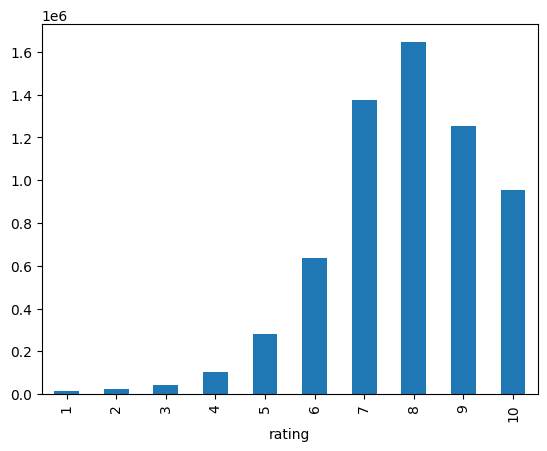

In [12]:
ratings_clean["rating"].value_counts().sort_index().plot(kind="bar")

In [13]:
popular_anime = anime_clean.sort_values(by="members", ascending=False)

popular_anime[["name", "type", "rating", "members"]].head(10)

,name,type,rating,members
40,Death Note,TV,8.71,1013917
86,Shingeki no Kyojin,TV,8.54,896229
804,Sword Art Online,TV,7.83,893100
1,Fullmetal Alchemist: Brotherhood,TV,9.26,793665
159,Angel Beats!,TV,8.39,717796
19,Code Geass: Hangyaku no Lelouch,TV,8.83,715151
841,Naruto,TV,7.81,683297
3,Steins;Gate,TV,9.17,673572
445,Mirai Nikki (TV),TV,8.07,657190
131,Toradora!,TV,8.45,633817


In [14]:
top_rated_anime = anime_clean.sort_values(by="rating",ascending=False)
top_rated_anime[["name","type","rating","members"]].head(10)


,name,type,rating,members
10464,Taka no Tsume 8: Yoshida-kun no X-Files,Movie,10.00,13
10400,Spoon-hime no Swing Kitchen,TV,9.60,47
9595,Mogura no Motoro,Movie,9.50,62
0,Kimi no Na wa.,Movie,9.37,200630
9078,Kahei no Umi,Movie,9.33,44
1,Fullmetal Alchemist: Brotherhood,TV,9.26,793665
10786,Yakusoku: Africa Mizu to Midori,OVA,9.25,53
2,Gintama°,TV,9.25,114262
3,Steins;Gate,TV,9.17,673572
4,Gintama&#039;,TV,9.16,151266


In [15]:
top_rated_popular = anime_clean[anime_clean['members']> 10000].sort_values(by="rating",ascending=False)

top_rated_popular[["name","type","rating","members"]].head(10)

,name,type,rating,members
0,Kimi no Na wa.,Movie,9.37,200630
1,Fullmetal Alchemist: Brotherhood,TV,9.26,793665
2,Gintama°,TV,9.25,114262
3,Steins;Gate,TV,9.17,673572
4,Gintama&#039;,TV,9.16,151266
5,Haikyuu!!: Karasuno Koukou VS Shiratorizawa Ga...,TV,9.15,93351
6,Hunter x Hunter (2011),TV,9.13,425855
7,Ginga Eiyuu Densetsu,OVA,9.11,80679
9,Gintama&#039;: Enchousen,TV,9.11,81109
8,Gintama Movie: Kanketsu-hen - Yorozuya yo Eien...,Movie,9.10,72534


<Axes: xlabel='type'>

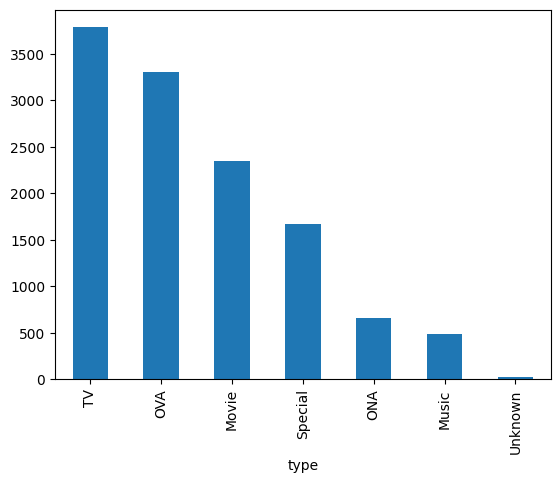

In [16]:
anime_clean["type"].value_counts().plot(kind="bar")

In [18]:
from collections import Counter

genre_counter = Counter()

for genres in anime_clean["genre"]:
    for genre in genres.split(", "):
        genre_counter[genre] += 1

genre_df = pd.DataFrame(
    genre_counter.items(),
    columns=["genre","count"]

).sort_values(by="count",ascending=False)

genre_df.head(10)



,genre,count
10,Comedy,4645
4,Action,2845
5,Adventure,2348
6,Fantasy,2309
14,Sci-Fi,2070
0,Drama,2016
9,Shounen,1712
38,Kids,1609
1,Romance,1464
19,Slice of Life,1220


In [19]:
user_rating_counts = ratings_clean.groupby("user_id")["anime_id"].count()
user_rating_counts.describe()

count    69600.000000
mean        91.052313
std        135.764253
min          1.000000
25%         13.000000
50%         45.000000
75%        114.000000
max       3747.000000
Name: anime_id, dtype: float64

<Axes: ylabel='Frequency'>

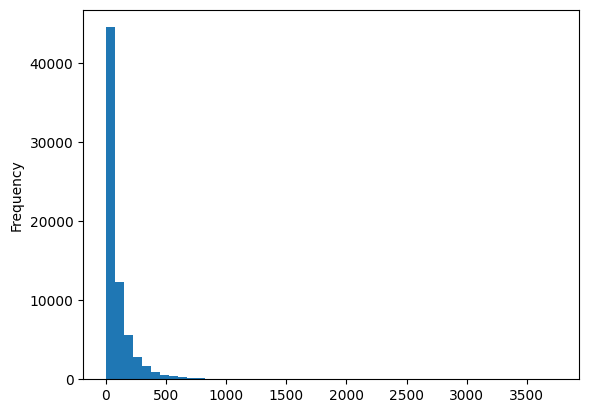

In [20]:
user_rating_counts.plot(kind="hist", bins=50)

In [21]:
anime_rating_counts = ratings_clean.groupby("anime_id")["user_id"].count()

anime_rating_counts.describe()

count     9927.000000
mean       638.384305
std       1795.865541
min          1.000000
25%          9.000000
50%         57.000000
75%        395.000000
max      34226.000000
Name: user_id, dtype: float64

In [24]:
anime_ratings = ratings_clean.merge(
    anime_clean[["anime_id","name","genre","type","rating","members"]],
    on="anime_id"
)

anime_ratings.head(10)

,user_id,anime_id,rating_x,name,genre,type,rating_y,members
0,1,8074,10,Highschool of the Dead,"Action, Ecchi, Horror, Supernatural",TV,7.46,535892
1,1,11617,10,High School DxD,"Comedy, Demons, Ecchi, Harem, Romance, School",TV,7.70,398660
2,1,11757,10,Sword Art Online,"Action, Adventure, Fantasy, Game, Romance",TV,7.83,893100
3,1,15451,10,High School DxD New,"Action, Comedy, Demons, Ecchi, Harem, Romance,...",TV,7.87,266657
4,2,11771,10,Kuroko no Basket,"Comedy, School, Shounen, Sports",TV,8.46,338315
5,3,20,8,Naruto,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,7.81,683297
6,3,154,6,Shaman King,"Action, Adventure, Comedy, Drama, Shounen, Sup...",TV,7.83,169517
7,3,170,9,Slam Dunk,"Comedy, Drama, School, Shounen, Sports",TV,8.56,82570
8,3,199,10,Sen to Chihiro no Kamikakushi,"Adventure, Drama, Supernatural",Movie,8.93,466254
9,3,225,9,Dragon Ball GT,"Action, Adventure, Comedy, Fantasy, Magic, Sci...",TV,6.72,226625


In [25]:
popular_recommendations = anime_clean[
    anime_clean["members"] > 10000
].sort_values(
    by=["rating", "members"],
    ascending=False
)

popular_recommendations[["name", "type", "genre", "rating", "members"]].head(10)

,name,type,genre,rating,members
0,Kimi no Na wa.,Movie,"Drama, Romance, School, Supernatural",9.37,200630
1,Fullmetal Alchemist: Brotherhood,TV,"Action, Adventure, Drama, Fantasy, Magic, Mili...",9.26,793665
2,Gintama°,TV,"Action, Comedy, Historical, Parody, Samurai, S...",9.25,114262
3,Steins;Gate,TV,"Sci-Fi, Thriller",9.17,673572
4,Gintama&#039;,TV,"Action, Comedy, Historical, Parody, Samurai, S...",9.16,151266
5,Haikyuu!!: Karasuno Koukou VS Shiratorizawa Ga...,TV,"Comedy, Drama, School, Shounen, Sports",9.15,93351
6,Hunter x Hunter (2011),TV,"Action, Adventure, Shounen, Super Power",9.13,425855
9,Gintama&#039;: Enchousen,TV,"Action, Comedy, Historical, Parody, Samurai, S...",9.11,81109
7,Ginga Eiyuu Densetsu,OVA,"Drama, Military, Sci-Fi, Space",9.11,80679
8,Gintama Movie: Kanketsu-hen - Yorozuya yo Eien...,Movie,"Action, Comedy, Historical, Parody, Samurai, S...",9.10,72534
